# Jawad Hassan
# 2230-0035
# BS AI
# ANN
# Lab 06


In [13]:
#libraries:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow.keras.layers import Dense,Dropout
from tensorflow.keras.models import Sequential
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras.optimizers import Adam

In [7]:
df =pd.read_csv("/Users/macbook/Desktop/sem6/ANN/lab6/heart.csv")
print(df.head())
x=df.drop('target',axis=1)
y=df['target']
xtrain,xtest,ytrain,ytest=train_test_split(x,y,test_size=0.2,random_state=42)
scale=StandardScaler()
xtrainscale=scale.fit_transform(xtrain)
xtestscale=scale.transform(xtest)

   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   52    1   0       125   212    0        1      168      0      1.0      2   
1   53    1   0       140   203    1        0      155      1      3.1      0   
2   70    1   0       145   174    0        1      125      1      2.6      0   
3   61    1   0       148   203    0        1      161      0      0.0      2   
4   62    0   0       138   294    1        1      106      0      1.9      1   

   ca  thal  target  
0   2     3       0  
1   0     3       0  
2   0     3       0  
3   1     3       0  
4   3     2       0  


In [9]:
#Task1

model1=Sequential([
  Dense(16,activation='relu',input_shape=(xtrain.shape[1],)), #1 hidden layer
  Dense(1,activation='sigmoid')  
])
model1.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])
history1=model1.fit(xtrainscale,ytrain,epochs=50,batch_size=10,validation_data=(xtestscale,ytest),verbose=1)
print(f"Baseline Accuracy: {model1.evaluate(xtestscale, ytest, verbose=0)[1]:.4f}")

Epoch 1/50


/Users/macbook/Desktop/env/lib/python3.9/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.5654 - loss: 0.6931 - val_accuracy: 0.6878 - val_loss: 0.5803
Epoch 2/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7890 - loss: 0.4842 - val_accuracy: 0.7659 - val_loss: 0.5025
Epoch 3/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8201 - loss: 0.4085 - val_accuracy: 0.7707 - val_loss: 0.4689
Epoch 4/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8208 - loss: 0.3931 - val_accuracy: 0.7707 - val_loss: 0.4519
Epoch 5/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8695 - loss: 0.3174 - val_accuracy: 0.7707 - val_loss: 0.4401
Epoch 6/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8410 - loss: 0.3449 - val_accuracy: 0.7756 - val_loss: 0.4307
Epoch 7/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8413 - loss: 0.3591 - val_accuracy: 0.7805 - val_loss: 0.4241
Epoch 8/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8704 - loss: 0.3122 - val_accuracy: 0.7805 - val_loss: 0.4192
Epo

In [12]:
#add more hidden layers:
neurons=[64,32,16,8]
results={}
for n in neurons:  
    model2= Sequential([
        Dense(n,activation='relu',input_shape=(xtrain.shape[1],)) ,
        Dense(n//2,activation='relu'),
        Dense(1,activation='sigmoid')     
    ])
    model2.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])
    history=model2.fit(xtrainscale,ytrain,epochs=50,verbose=0,batch_size=10,validation_data=(xtestscale,ytest))
    acc = model2.evaluate(xtestscale, ytest, verbose=0)[1]
    results[n] = acc
    print(f"Neurons: {n} (Layer 1) & {n//2} (Layer 2) -> Accuracy: {acc:.4f}")
    

Neurons: 64 (Layer 1) & 32 (Layer 2) -> Accuracy: 0.9854
Neurons: 32 (Layer 1) & 16 (Layer 2) -> Accuracy: 0.9854
Neurons: 16 (Layer 1) & 8 (Layer 2) -> Accuracy: 0.9366
Neurons: 8 (Layer 1) & 4 (Layer 2) -> Accuracy: 0.8439


## Comparison:
### As we decreased the neurons the model accuracy also started decreasing so we can see that model performs best when we increase the neurons to layer 1 -> 64 and layer 2 -> 32, also increasing the hidden layers as well. the accuracy went from 98% to 84%.

In [16]:
#Task2 
learning_rates = [0.001, 0.01]
epochs_list = [50, 100]
all_histories = {}
final_accuracies = {}
for lr in learning_rates:
    for ep in epochs_list:
        model = Sequential([
            Dense(16, activation='relu', input_shape=(xtrain.shape[1],)),
            Dense(8, activation='relu'),
            Dense(1, activation='sigmoid')
        ])
        
        # Manually set the Learning Rate
        opt = Adam(learning_rate=lr)
        model.compile(optimizer=opt, loss='binary_crossentropy', metrics=['accuracy'])
        
        # Train
        h = model.fit(xtrainscale, ytrain, 
                      epochs=ep, 
                      batch_size=10, 
                      validation_data=(xtestscale, ytest), 
                      verbose=0)
        
        loss, accuracy = model.evaluate(xtestscale, ytest, verbose=0)
        
        # Store both history and final accuracy
        key = f"LR:{lr}_EP:{ep}"
        all_histories[key] = h
        final_accuracies[key] = accuracy
        
        print(f"Finished Training -> {key} | Test Accuracy: {accuracy:.4f}")

# Final Summary Printout
print("\n" + "="*30)
print("FINAL ACCURACY COMPARISON")
print("="*30)
for setting, acc in final_accuracies.items():
    print(f"{setting.ljust(15)} : {acc*100:.2f}%")

Finished Training -> LR:0.001_EP:50 | Test Accuracy: 0.9463
Finished Training -> LR:0.001_EP:100 | Test Accuracy: 0.9854
Finished Training -> LR:0.01_EP:50 | Test Accuracy: 0.9854
Finished Training -> LR:0.01_EP:100 | Test Accuracy: 0.9854

FINAL ACCURACY COMPARISON
LR:0.001_EP:50  : 94.63%
LR:0.001_EP:100 : 98.54%
LR:0.01_EP:50   : 98.54%
LR:0.01_EP:100  : 98.54%


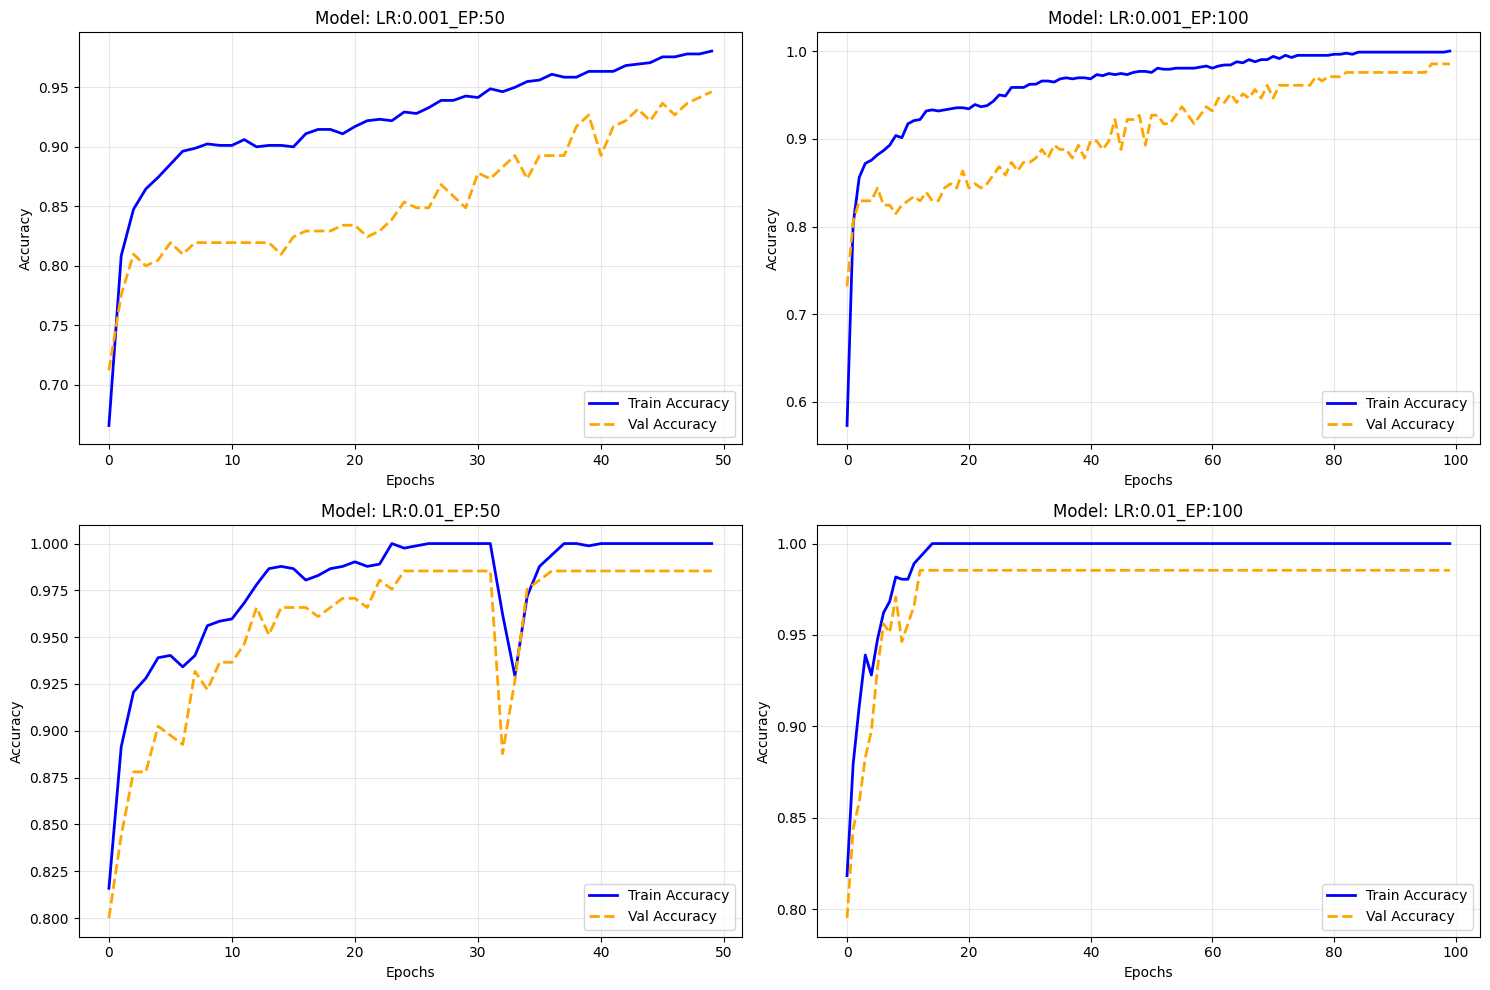

In [17]:
#visualize
plt.figure(figsize=(15, 10))

for i, (key, h) in enumerate(all_histories.items(), 1):
    plt.subplot(2, 2, i)
    
    # Plot Training Accuracy
    plt.plot(h.history['accuracy'], label='Train Accuracy', color='blue', lw=2)
    # Plot Validation Accuracy
    plt.plot(h.history['val_accuracy'], label='Val Accuracy', color='orange', linestyle='--', lw=2)
    
    plt.title(f"Model: {key}")
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend(loc='lower right')
    plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Findings:
### the results above show that when we use 0.001 lr the accuracy slowly and gradually increases and with 100 epoch it performs better.
### However, when we use 0.01 lr we see a sudden spike and the model crashes so its very unpredictable using such less lr.
## Conclusion:
### If we had to pick one model to use for real patients, the winner is LR: 0.001 and EP: 100.
